# 03. ChannelTokenFormer -- адаптация обработки пропусков

[Статья](https://arxiv.org/abs/2506.08660), [код авторов](https://github.com/jinkwan1115/ChannelTokenFormer).

Хочу сохранить тот же pairwise-backbone и изменить способ работы с отсутствующими данными.
Поэтому делаю **CTF-inspired adapter**, а не заявляю полное воспроизведение forecasting-модели.
Adapter получает наблюдения и явную маску, затем формирует плотное представление для исходной CNN.
Скрытые исходные значения ему недоступны. Обучение -- только по меткам активности.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
for folder in ["data", "figures", "results"]:
    (ROOT / folder).mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

from copy import deepcopy
import platform
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 35
PATIENCE = 7
LR = 8e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
data = np.load(ROOT / "data/uci_har_missing.npz")
meta = json.loads((ROOT / "data/metadata.json").read_text())
X_train, y_train = data["X_train"], data["y_train"]
y_test, subjects_test = data["y_test"], data["subjects_test"]
fold_id, steps = data["fold_id"], data["steps"]
CLASS_NAMES = meta["classes"]

hardware = {
    "device": str(device), "platform": platform.platform(), "machine": platform.machine(),
    "processor": platform.processor(), "python": platform.python_version(),
    "torch": torch.__version__, "numpy": np.__version__, "threads": torch.get_num_threads(),
    "accelerator": torch.cuda.get_device_name(0) if device.type == "cuda" else str(device),
}
print(hardware)


{'device': 'mps', 'platform': 'macOS-15.7.7-arm64-arm-64bit-Mach-O', 'machine': 'arm64', 'processor': 'arm', 'python': '3.14.6', 'torch': '2.14.0', 'numpy': '2.5.3', 'threads': 10, 'accelerator': 'mps'}


### Протокол и общий backbone

Те же CV, optimizer, scheduler и early stopping, что у четырех заполнений.
В каждом CV fold использую тот же fold seed, что и в baseline; финальный seed тоже общий.
Код общих блоков повторен, чтобы ноутбук запускался самостоятельно, без `%run` и скрытых зависимостей.


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def fit_stats(X):
    # Только наблюдаемые значения текущего train fold.
    return {
        "mean": np.nanmean(X, axis=(0, 2), keepdims=True),
        "median": np.nanmedian(X, axis=(0, 2), keepdims=True),
        "std": np.nanstd(X, axis=(0, 2), keepdims=True) + 1e-6,
    }


def prepare(X, stats, method):
    observed = np.isfinite(X)
    if method == "linear":
        filled = X.copy()
        grid = np.arange(X.shape[-1])
        for i in range(len(X)):
            for c in range(X.shape[1]):
                keep = observed[i, c]
                # На краях -- ближайшее наблюдение; пустой канал -- train mean.
                filled[i, c] = np.interp(grid, grid[keep], X[i, c, keep]) if keep.any() else stats["mean"][0, c, 0]
    elif method == "zero":
        filled = np.where(observed, X, 0.0)
    elif method in ["mean", "median"]:
        filled = np.where(observed, X, stats[method])
    else:
        # Нулевое хранение после нормализации -- значение не считается наблюдением.
        filled = np.where(observed, X, stats["mean"])
    scaled = ((filled - stats["mean"]) / stats["std"]).astype("float32")
    return scaled, observed


def make_loader(X, mask, y, shuffle=False, seed=SEED):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(mask), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(seed), num_workers=0)


def sync():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    truth, prediction = [], []
    loss_sum = 0.0
    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        logits = model(X, mask)
        loss_sum += F.cross_entropy(logits, y).item() * len(y)
        truth.extend(y.cpu().numpy())
        prediction.extend(logits.argmax(1).cpu().numpy())
    return {
        "loss": loss_sum / len(truth),
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "macro_f1": f1_score(truth, prediction, labels=range(6), average="macro", zero_division=0),
        "y_true": np.asarray(truth), "y_pred": np.asarray(prediction),
    }


def fit(model, train_loader, val_loader=None, epochs=MAX_EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    # Один и тот же горизонт scheduler в CV и финальном обучении.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    history = []
    best_f1, best_epoch, best_state = -1.0, 0, None
    sync()
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, total = 0.0, 0
        for X, mask, y in train_loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(X, mask), y, label_smoothing=LABEL_SMOOTHING)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            total += len(y)
        scheduler.step()
        row = {"epoch": epoch, "train_loss": loss_sum / total}
        if val_loader is not None:
            val = evaluate(model, val_loader)
            row.update(val_loss=val["loss"], val_f1=val["macro_f1"])
            if val["macro_f1"] > best_f1:
                best_f1, best_epoch = val["macro_f1"], epoch
                best_state = deepcopy(model.state_dict())
        history.append(row)
        print(f"epoch {epoch:02d} -- loss {row['train_loss']:.4f}" +
              (f" -- val F1 {row['val_f1']:.4f}" if val_loader is not None else ""))
        if val_loader is not None and epoch - best_epoch >= PATIENCE:
            break
    sync()
    elapsed = time.perf_counter() - started
    if val_loader is not None:
        model.load_state_dict(best_state)
    return history, best_epoch, elapsed


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def latency_ms(model, X, mask, repeats=30):
    model.eval()
    batch = torch.from_numpy(X[:BATCH_SIZE]).to(device)
    batch_mask = torch.from_numpy(mask[:BATCH_SIZE]).to(device)
    for _ in range(10):
        model(batch, batch_mask)
    sync()
    started = time.perf_counter()
    for _ in range(repeats):
        model(batch, batch_mask)
    sync()
    return (time.perf_counter() - started) * 1000 / repeats / len(batch)


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class PairwiseTemporalIMP(nn.Module):
    # Для каждой пары latent channels учу свой temporal kernel --
    # так получаю отдельную banded Toeplitz matrix для связи source -> target.
    def __init__(self, channels, seq_len=128, kernel_size=5):
        super().__init__()
        self.mix = nn.Conv1d(
            channels, channels, kernel_size,
            padding=kernel_size // 2, bias=False,
        )
        self.bn = nn.BatchNorm1d(seq_len)

    def forward(self, x):
        message = self.mix(x)
        x = (x + message).transpose(1, 2)
        return F.relu(self.bn(x).transpose(1, 2))


class SKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv3 = nn.Conv1d(channels, channels, 3, padding=1, groups=channels, bias=False)
        self.conv1 = nn.Conv1d(channels, channels, 1, groups=channels, bias=False)
        self.bn3 = nn.BatchNorm1d(channels)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn_id = nn.BatchNorm1d(channels)

    def forward(self, x):
        return F.relu(self.bn3(self.conv3(x)) + self.bn1(self.conv1(x)) + self.bn_id(x))


class LKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.origin = nn.Sequential(
            nn.Conv1d(channels, channels, 47, padding=23, groups=channels, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.branches = nn.ModuleList()
        for kernel, dilation in zip([5, 23, 3, 3, 3], [1, 2, 21, 19, 17]):
            padding = (dilation * (kernel - 1) + 1) // 2
            self.branches.append(nn.Sequential(
                nn.Conv1d(
                    channels, channels, kernel,
                    padding=padding, dilation=dilation,
                    groups=channels, bias=False,
                ),
                nn.BatchNorm1d(channels),
            ))

    def forward(self, x):
        out = self.origin(x)
        for branch in self.branches:
            out = out + branch(x)
        return out + x


class PairwiseEdgeMTSC(nn.Module):
    def __init__(self, hidden=(176, 44), temporal_kernel=5, dropout=0.2):
        super().__init__()
        h1, h2 = hidden

        self.up1 = ConvBlock(9, h1)
        self.imp1 = PairwiseTemporalIMP(h1, kernel_size=temporal_kernel)
        self.skb = SKB(h1)

        self.up2 = ConvBlock(h1, h2)
        self.imp2 = PairwiseTemporalIMP(h2, kernel_size=temporal_kernel)
        self.lkb = LKB(h2)

        self.linear_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(h2, 6)
        )
        self.conv_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(h2, 6, 1),
            nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Flatten(),
        )

    def forward(self, x, mask=None):
        x = self.skb(self.imp1(self.up1(x)))
        x = self.imp2(self.up2(x))
        x = F.relu(self.lkb(x) + x)
        return (self.linear_head(x) + self.conv_head(x)) / 2


### Раздельное время и обмен каналов

Канал беру на его собственной редкой сетке. Размеры patches -- около 0.32 с,
в отсчетах `[16, 8, 5, 4, 3, 8, 5, 4, 3]`. Это sampling-aware упрощение, без FFT.
Проекции общие для одинаковых размеров patch. К token добавляю канал и исходную временную позицию.

Local tokens видят local tokens своего канала. Channel token видит свои local и channel tokens
других каналов; собственный channel token исключен из ключей. Два attention-блока дают возможность
обменяться уже агрегированной временной информацией.

Пустые patches исключаю из ключей; частично наблюдаемый patch получает значения и бинарную маску.
Padding не считается наблюдением. Случайный patch dropout применяется только при обучении
и также убирает скрытый patch из прямого пути к backbone. Даже полностью пустой канал не дает NaN.

Декодер channel token формирует 128 позиций, заменяю ими только отсутствующую часть входа CNN.
Это обучаемое представление для классификации -- не реконструкция с гарантией физического смысла.
В статье channel tokens декодируются в прогноз; здесь это осознанная адаптация под общий backbone.


In [4]:
class MaskedAttentionBlock(nn.Module):
    def __init__(self, dim=32, heads=4, dropout=0.1):
        super().__init__()
        self.heads = heads
        self.norm1 = nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, 2 * dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * dim, dim))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, allowed, valid):
        b, n, d = x.shape
        qkv = self.qkv(self.norm1(x)).reshape(b, n, 3, self.heads, d // self.heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        scores = (q @ k.transpose(-2, -1)) / (d // self.heads) ** 0.5
        keep = allowed[None, None] & valid[:, None, None, :]
        weights = scores.masked_fill(~keep, -1e4).softmax(dim=-1) * keep
        # Полностью пустой канал допустим -- пустая строка attention дает нулевое сообщение.
        weights = weights / weights.sum(-1, keepdim=True).clamp_min(1e-8)
        message = (self.dropout(weights) @ v).transpose(1, 2).reshape(b, n, d)
        x = x + self.dropout(self.proj(message))
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x * valid[..., None]


class ChannelTokenAdapter(nn.Module):
    def __init__(self, steps, dim=32, patch_drop=0.15, cross_channel=True, use_mask=True):
        super().__init__()
        self.steps = tuple(int(s) for s in steps)
        # Sampling-aware patching -- около 0.32 с на patch; FFT здесь не использую.
        self.patch_sizes = tuple(max(2, round(16 / s)) for s in self.steps)
        self.patch_drop, self.use_mask = patch_drop, use_mask
        self.cross_channel = cross_channel
        self.projectors = nn.ModuleDict({str(p): nn.Linear(2 * p, dim) for p in sorted(set(self.patch_sizes))})
        self.channel_embedding = nn.Parameter(torch.randn(9, dim) * 0.02)
        self.channel_tokens = nn.Parameter(torch.randn(9, dim) * 0.02)
        self.blocks = nn.ModuleList([MaskedAttentionBlock(dim) for _ in range(2)])
        self.decoders = nn.ModuleDict({str(s): nn.Linear(dim, 128) for s in sorted(set(self.steps))})

        owners, globals_, centers = [], [], []
        self.summary_indices = []
        for c, (s, p) in enumerate(zip(self.steps, self.patch_sizes)):
            count = (len(range(0, 128, s)) + p - 1) // p
            owners.extend([c] * count + [c])
            globals_.extend([False] * count + [True])
            centers.extend([(j * p + (p - 1) / 2) * s for j in range(count)] + [0])
            self.summary_indices.append(len(owners) - 1)
        owners, global_token = torch.tensor(owners), torch.tensor(globals_)
        same = owners[:, None] == owners[None, :]
        # Local -> local своего канала; channel token -> свои local и чужие channel tokens.
        allowed = same & ~global_token[None, :]
        if cross_channel:
            allowed |= global_token[:, None] & global_token[None, :] & ~same
        self.register_buffer("allowed", allowed)
        angle = torch.tensor(centers)[:, None] / 128 * torch.exp(
            torch.arange(0, dim, 2).float() * (-np.log(10000.0) / dim)) * 2 * np.pi
        pos = torch.zeros(len(owners), dim)
        pos[:, 0::2], pos[:, 1::2] = angle.sin(), angle.cos()
        pos[global_token] = 0
        self.register_buffer("positions", pos)

    def forward(self, x, observed):
        all_tokens, all_valid = [], []
        effective = observed.clone()
        for c, (step, patch) in enumerate(zip(self.steps, self.patch_sizes)):
            values, seen = x[:, c, ::step], observed[:, c, ::step]
            length = values.shape[1]
            pad = (-length) % patch
            values = F.pad(values, (0, pad)).reshape(len(x), -1, patch)
            seen = F.pad(seen, (0, pad), value=False).reshape(len(x), -1, patch)
            if self.training and self.patch_drop > 0:
                keep_patch = torch.rand(seen.shape[:2], device=x.device) >= self.patch_drop
                seen = seen & keep_patch[..., None]
                # Скрытый patch не обходит adapter через исходный ряд.
                effective[:, c, ::step] = seen.flatten(1)[:, :length]
            if self.use_mask:
                values = values.masked_fill(~seen, 0)
                features = torch.cat([values, seen.to(values.dtype)], dim=-1)
                valid = seen.any(-1)
            else:
                # Контроль: технические нули считаю обычным входом, маску не передаю в tokens.
                padding_mask = F.pad(torch.ones(len(x), length, device=x.device), (0, pad))
                padding_mask = padding_mask.reshape_as(values)
                features = torch.cat([values, padding_mask], dim=-1)
                valid = torch.ones(values.shape[:2], dtype=torch.bool, device=x.device)
            tokens = self.projectors[str(patch)](features) + self.channel_embedding[c]
            summary = (self.channel_tokens[c] + self.channel_embedding[c]).expand(len(x), 1, -1)
            all_tokens.append(torch.cat([tokens, summary], dim=1))
            all_valid.append(torch.cat([valid, torch.ones(len(x), 1, dtype=torch.bool, device=x.device)], dim=1))
        tokens = torch.cat(all_tokens, dim=1) + self.positions
        valid = torch.cat(all_valid, dim=1)
        tokens = tokens * valid[..., None]
        for block in self.blocks:
            tokens = block(tokens, self.allowed, valid)
        summaries = tokens[:, self.summary_indices]
        decoded = torch.stack([self.decoders[str(s)](summaries[:, c]) for c, s in enumerate(self.steps)], dim=1)
        # Наблюдения сохраняю, отсутствующие позиции задает обучаемое представление.
        return torch.where(effective, x, decoded)


class ChannelTokenPairwise(nn.Module):
    def __init__(self, patch_drop=0.15, cross_channel=True, use_mask=True):
        super().__init__()
        # Backbone и его начальные веса совпадают с baseline при одном seed.
        self.backbone = PairwiseEdgeMTSC()
        self.adapter = ChannelTokenAdapter(steps, patch_drop=patch_drop,
                                           cross_channel=cross_channel, use_mask=use_mask)

    def forward(self, x, mask):
        return self.backbone(self.adapter(x, mask))


In [5]:
set_seed(SEED)
model = ChannelTokenPairwise()
print("backbone params:", count_parameters(model.backbone))
print("adapter params:", count_parameters(model.adapter))
print("total params:", count_parameters(model))
print("patch sizes:", model.adapter.patch_sizes)


backbone params: 181376
adapter params: 41248
total params: 222624
patch sizes: (16, 8, 5, 4, 3, 8, 5, 4, 3)


### Четыре конфигурации

- Full -- маска наблюдений, patch dropout и обмен channel tokens.
- Без patch dropout -- маска реальных пропусков сохраняется.
- Без token exchange -- убираю только дополнительный обмен в adapter; CNN остается прежней.
- Filled tokens -- та же архитектура и число параметров, без token-маски и без patch dropout.

В filled tokens технический ноль после стандартизации считается обычным входом.
Маска используется лишь для общего для всех adapter-вариантов сохранения наблюдаемых позиций.
Это контроль именно маскирования tokens. Он не тождественен physical-zero baseline.
`no_patch_drop` vs `filled_tokens` отличается только обработкой наблюдаемости в adapter.


In [6]:
def run_experiment(name, factory, method):
    cv_rows, histories = [], []
    for fold in range(3):
        seed = SEED + fold + 1
        set_seed(seed)
        fit_idx, val_idx = fold_id != fold, fold_id == fold
        stats = fit_stats(X_train[fit_idx])
        X_fit, M_fit = prepare(X_train[fit_idx], stats, method)
        X_val, M_val = prepare(X_train[val_idx], stats, method)
        train_loader = make_loader(X_fit, M_fit, y_train[fit_idx], True, seed)
        val_loader = make_loader(X_val, M_val, y_train[val_idx])
        model = factory().to(device)
        print(name, "-- fold", fold + 1)
        history, best_epoch, elapsed = fit(model, train_loader, val_loader)
        val = evaluate(model, val_loader)
        cv_rows.append({"fold": fold + 1, "best_epoch": best_epoch, "time_s": elapsed,
                        **{k: val[k] for k in ["accuracy", "balanced_accuracy", "macro_f1"]}})
        histories.extend([dict(fold=fold + 1, **row) for row in history])
    cv = pd.DataFrame(cv_rows)
    cv.to_csv(ROOT / f"results/{name}_cv.csv", index=False)
    pd.DataFrame(histories).to_csv(ROOT / f"results/{name}_history.csv", index=False)

    # Число эпох выбираю по CV -- test до этого не участвует ни в одном решении.
    epochs = max(1, int(np.median(cv["best_epoch"])))
    stats = fit_stats(X_train)
    set_seed(SEED)
    model = factory().to(device)
    X_fit, M_fit = prepare(X_train, stats, method)
    final_history, _, elapsed = fit(model, make_loader(X_fit, M_fit, y_train, True), epochs=epochs)
    pd.DataFrame(final_history).to_csv(ROOT / f"results/{name}_final_history.csv", index=False)
    np.savez(ROOT / f"results/{name}_stats.npz", **stats)
    torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, ROOT / f"results/{name}.pt")
    config = dict(model=name, imputation=method, seed=SEED, batch_size=BATCH_SIZE,
                  max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY,
                  label_smoothing=LABEL_SMOOTHING, final_epochs=epochs, data=meta,
                  hardware=hardware, architecture=str(model))
    if hasattr(model, "adapter"):
        config["adapter"] = {"patch_sizes": model.adapter.patch_sizes,
                             "patch_drop": model.adapter.patch_drop,
                             "use_mask": model.adapter.use_mask,
                             "cross_channel": model.adapter.cross_channel}
    (ROOT / f"results/{name}_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2))

    rows = []
    for missing in [0, 25, 50]:
        started = time.perf_counter()
        X_eval, M_eval = prepare(data[f"X_test_{missing}"], stats, method)
        prep_ms = (time.perf_counter() - started) * 1000 / len(X_eval)
        test = evaluate(model, make_loader(X_eval, M_eval, y_test))
        rows.append({
            "model": name, "gap_pct": missing, "params": count_parameters(model),
            "cv_f1_mean": cv["macro_f1"].mean(), "cv_f1_std": cv["macro_f1"].std(),
            "final_epochs": epochs, "train_time_s": elapsed, "cv_time_s": cv["time_s"].sum(),
            "latency_ms": latency_ms(model, X_eval, M_eval), "prepare_ms": prep_ms,
            **{k: test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1"]},
        })
        pd.DataFrame({"subject": subjects_test, "true": y_test, "pred": test["y_pred"]}).to_csv(
            ROOT / f"results/{name}_test_{missing}_predictions.csv", index=False)
        if missing == 25:
            report = pd.DataFrame(classification_report(
                y_test, test["y_pred"], labels=range(6), target_names=CLASS_NAMES,
                output_dict=True, zero_division=0)).T
            report.to_csv(ROOT / f"results/{name}_class_report.csv")
            plt.figure(figsize=(8, 6))
            sns.heatmap(confusion_matrix(y_test, test["y_pred"], labels=range(6)), annot=True,
                        fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
            plt.xlabel("pred"); plt.ylabel("true"); plt.title(name + " -- test 25%")
            plt.tight_layout()
            plt.savefig(ROOT / f"figures/{name}_confusion.png", dpi=150)
            plt.show()
    result = pd.DataFrame(rows)
    result.to_csv(ROOT / f"results/{name}_results.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for fold in range(1, 4):
        h = pd.DataFrame(histories).query("fold == @fold")
        axes[0].plot(h.epoch, h.train_loss, label=f"fold {fold}")
        axes[1].plot(h.epoch, h.val_f1, label=f"fold {fold}")
    axes[0].set_title("Train loss"); axes[1].set_title("Validation macro F1")
    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend()
    fig.suptitle(name)
    plt.tight_layout()
    plt.savefig(ROOT / f"figures/{name}_learning.png", dpi=150)
    plt.show()
    return result


03_full -- fold 1
epoch 01 -- loss 0.9405 -- val F1 0.9585
epoch 02 -- loss 0.5125 -- val F1 0.9380
epoch 03 -- loss 0.4216 -- val F1 0.9636
epoch 04 -- loss 0.3986 -- val F1 0.9607
epoch 05 -- loss 0.3875 -- val F1 0.9642
epoch 06 -- loss 0.3729 -- val F1 0.9657
epoch 07 -- loss 0.3665 -- val F1 0.9579
epoch 08 -- loss 0.3640 -- val F1 0.9423
epoch 09 -- loss 0.3571 -- val F1 0.9514
epoch 10 -- loss 0.3512 -- val F1 0.9597
epoch 11 -- loss 0.3516 -- val F1 0.9610
epoch 12 -- loss 0.3410 -- val F1 0.9589
epoch 13 -- loss 0.3415 -- val F1 0.9610
03_full -- fold 2
epoch 01 -- loss 0.9131 -- val F1 0.8273
epoch 02 -- loss 0.4249 -- val F1 0.8692
epoch 03 -- loss 0.3558 -- val F1 0.8638
epoch 04 -- loss 0.3381 -- val F1 0.8341
epoch 05 -- loss 0.3218 -- val F1 0.8515
epoch 06 -- loss 0.3192 -- val F1 0.8612
epoch 07 -- loss 0.3139 -- val F1 0.8769
epoch 08 -- loss 0.3082 -- val F1 0.8904
epoch 09 -- loss 0.3087 -- val F1 0.8693
epoch 10 -- loss 0.3077 -- val F1 0.8704
epoch 11 -- loss 0.29

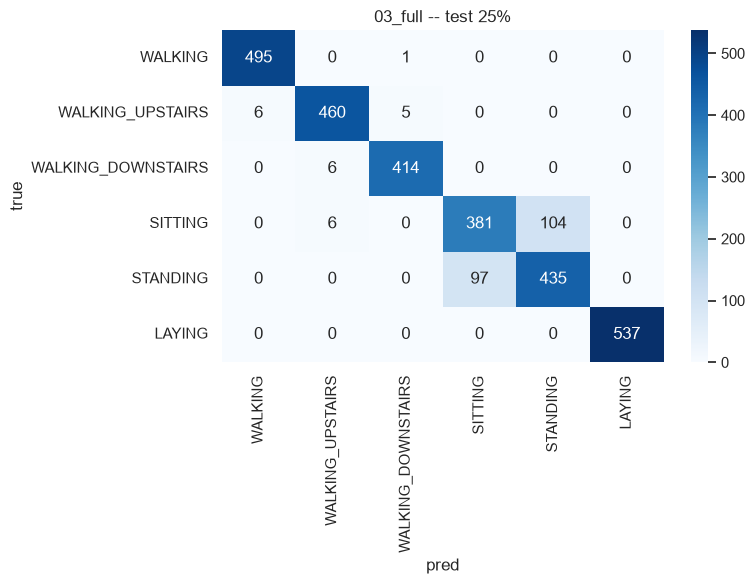

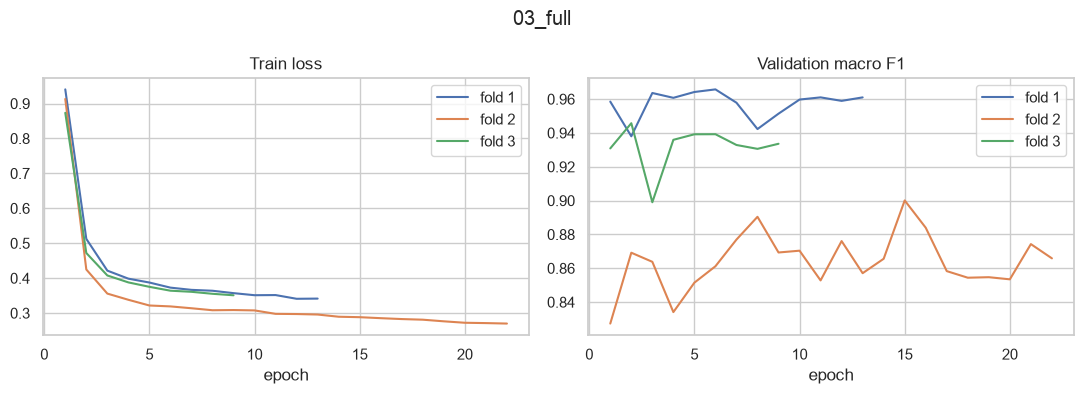

03_no_patch_drop -- fold 1
epoch 01 -- loss 0.8922 -- val F1 0.9577
epoch 02 -- loss 0.4727 -- val F1 0.9368
epoch 03 -- loss 0.4004 -- val F1 0.9632
epoch 04 -- loss 0.3810 -- val F1 0.9626
epoch 05 -- loss 0.3684 -- val F1 0.9576
epoch 06 -- loss 0.3605 -- val F1 0.9628
epoch 07 -- loss 0.3503 -- val F1 0.9626
epoch 08 -- loss 0.3509 -- val F1 0.9546
epoch 09 -- loss 0.3475 -- val F1 0.9577
epoch 10 -- loss 0.3396 -- val F1 0.9243
03_no_patch_drop -- fold 2
epoch 01 -- loss 0.8738 -- val F1 0.8430
epoch 02 -- loss 0.3823 -- val F1 0.8946
epoch 03 -- loss 0.3323 -- val F1 0.8603
epoch 04 -- loss 0.3188 -- val F1 0.8559
epoch 05 -- loss 0.3076 -- val F1 0.8564
epoch 06 -- loss 0.3064 -- val F1 0.8791
epoch 07 -- loss 0.3022 -- val F1 0.8533
epoch 08 -- loss 0.2940 -- val F1 0.8801
epoch 09 -- loss 0.2904 -- val F1 0.8642
03_no_patch_drop -- fold 3
epoch 01 -- loss 0.8188 -- val F1 0.9298
epoch 02 -- loss 0.4338 -- val F1 0.9494
epoch 03 -- loss 0.3879 -- val F1 0.9252
epoch 04 -- loss 

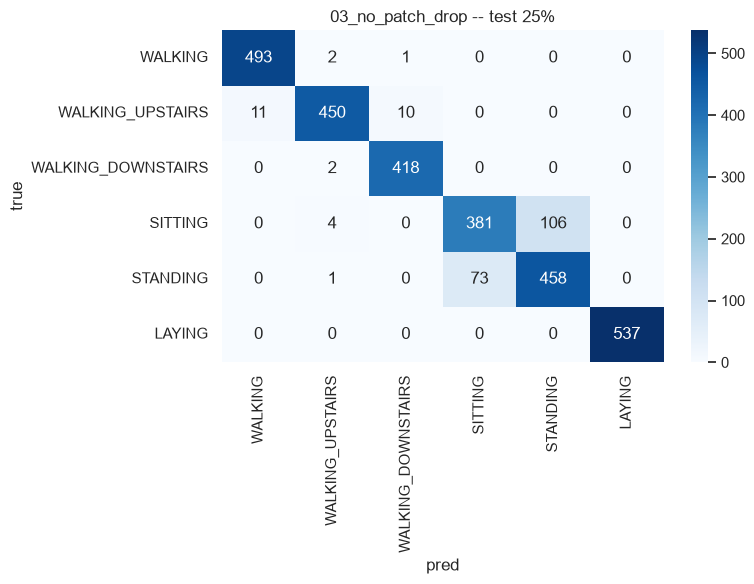

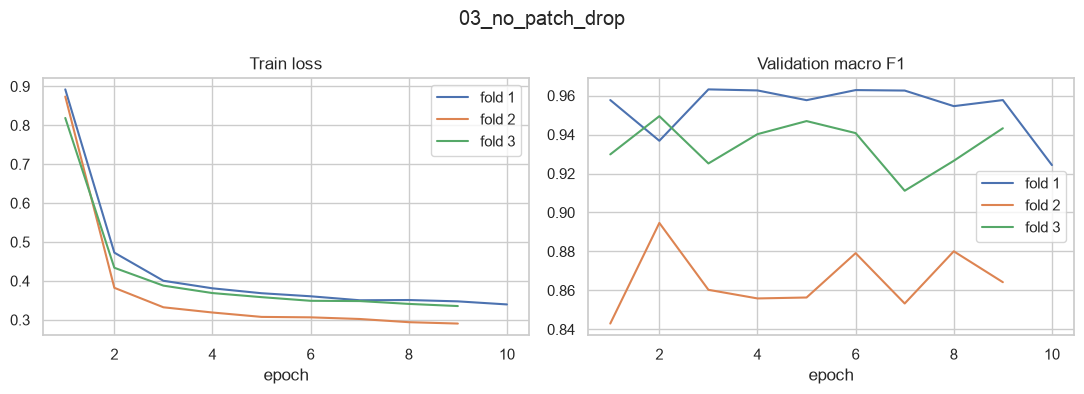

03_no_token_exchange -- fold 1
epoch 01 -- loss 0.9302 -- val F1 0.9427
epoch 02 -- loss 0.5081 -- val F1 0.9512
epoch 03 -- loss 0.4190 -- val F1 0.9562
epoch 04 -- loss 0.3981 -- val F1 0.9504
epoch 05 -- loss 0.3877 -- val F1 0.9497
epoch 06 -- loss 0.3750 -- val F1 0.9678
epoch 07 -- loss 0.3674 -- val F1 0.9485
epoch 08 -- loss 0.3645 -- val F1 0.9515
epoch 09 -- loss 0.3611 -- val F1 0.9373
epoch 10 -- loss 0.3561 -- val F1 0.9602
epoch 11 -- loss 0.3587 -- val F1 0.9662
epoch 12 -- loss 0.3488 -- val F1 0.9511
epoch 13 -- loss 0.3453 -- val F1 0.9653
03_no_token_exchange -- fold 2
epoch 01 -- loss 0.9122 -- val F1 0.8595
epoch 02 -- loss 0.4134 -- val F1 0.8524
epoch 03 -- loss 0.3546 -- val F1 0.8699
epoch 04 -- loss 0.3362 -- val F1 0.8342
epoch 05 -- loss 0.3181 -- val F1 0.8519
epoch 06 -- loss 0.3190 -- val F1 0.8634
epoch 07 -- loss 0.3121 -- val F1 0.8850
epoch 08 -- loss 0.3055 -- val F1 0.8906
epoch 09 -- loss 0.3053 -- val F1 0.8696
epoch 10 -- loss 0.3056 -- val F1 0.

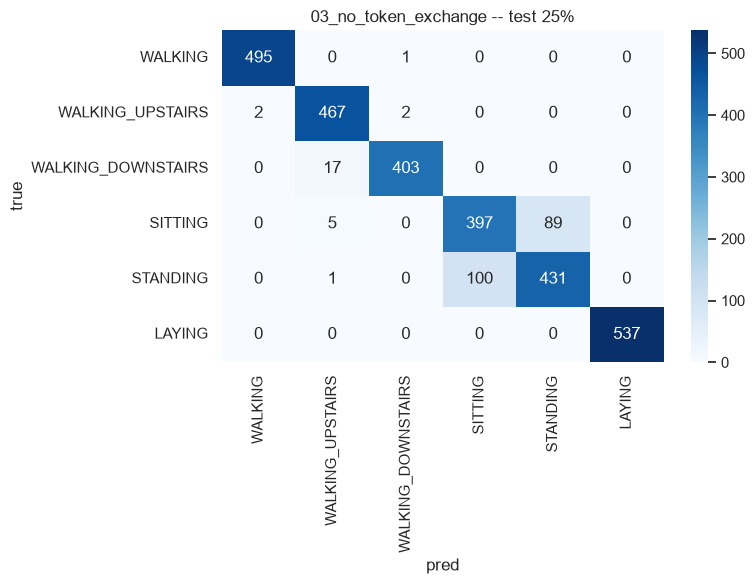

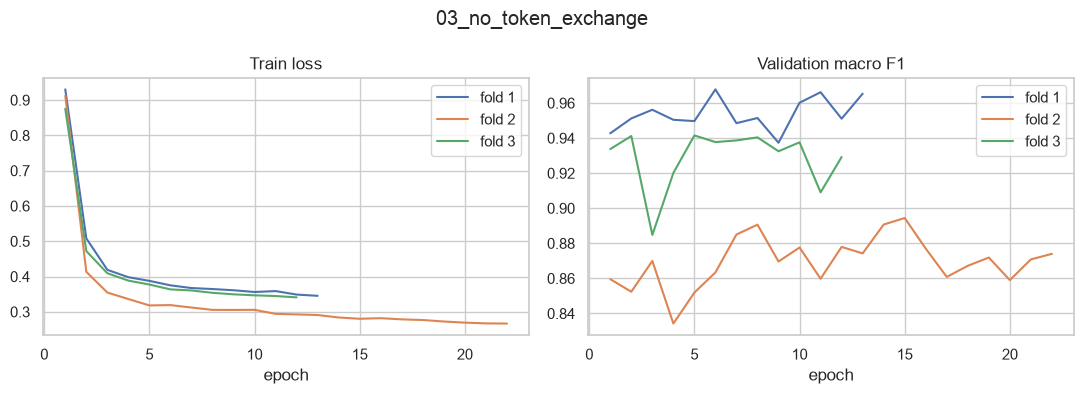

03_filled_tokens -- fold 1
epoch 01 -- loss 0.8942 -- val F1 0.9526
epoch 02 -- loss 0.4765 -- val F1 0.9342
epoch 03 -- loss 0.4029 -- val F1 0.9632
epoch 04 -- loss 0.3831 -- val F1 0.9602
epoch 05 -- loss 0.3692 -- val F1 0.9570
epoch 06 -- loss 0.3629 -- val F1 0.9649
epoch 07 -- loss 0.3546 -- val F1 0.9575
epoch 08 -- loss 0.3555 -- val F1 0.9302
epoch 09 -- loss 0.3490 -- val F1 0.9587
epoch 10 -- loss 0.3411 -- val F1 0.9336
epoch 11 -- loss 0.3431 -- val F1 0.9715
epoch 12 -- loss 0.3364 -- val F1 0.9262
epoch 13 -- loss 0.3322 -- val F1 0.9620
epoch 14 -- loss 0.3228 -- val F1 0.9124
epoch 15 -- loss 0.3231 -- val F1 0.9516
epoch 16 -- loss 0.3105 -- val F1 0.9691
epoch 17 -- loss 0.3115 -- val F1 0.9551
epoch 18 -- loss 0.3049 -- val F1 0.9671
03_filled_tokens -- fold 2
epoch 01 -- loss 0.8740 -- val F1 0.8324
epoch 02 -- loss 0.3838 -- val F1 0.8749
epoch 03 -- loss 0.3327 -- val F1 0.8663
epoch 04 -- loss 0.3188 -- val F1 0.8498
epoch 05 -- loss 0.3075 -- val F1 0.8509
epo

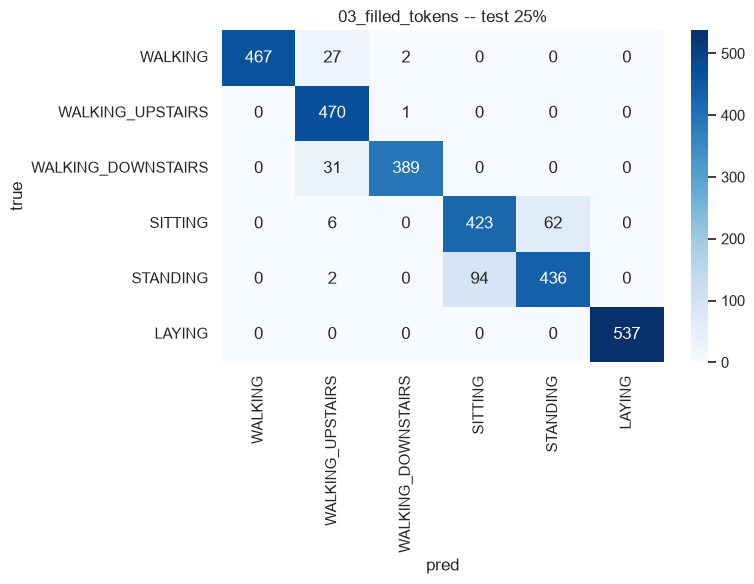

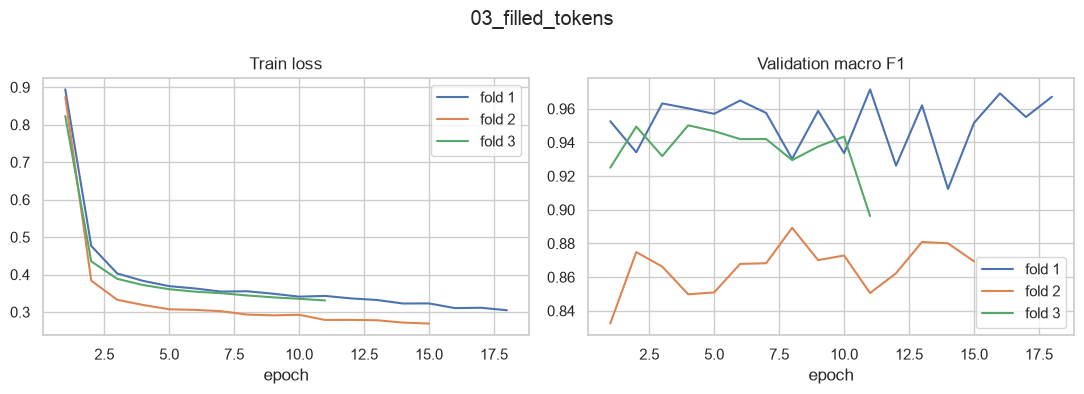

,model,gap_pct,params,cv_f1_mean,cv_f1_std,final_epochs,train_time_s,cv_time_s,latency_ms,prepare_ms,accuracy,balanced_accuracy,macro_f1
0,03_full,0,222624,0.9372,0.0336,6,14.8729,86.9734,0.0761,0.0067,0.9206,0.9219,0.9219
1,03_full,25,222624,0.9372,0.0336,6,14.8729,86.9734,0.0773,0.0071,0.9237,0.9257,0.9255
2,03_full,50,222624,0.9372,0.0336,6,14.8729,86.9734,0.0776,0.0056,0.9091,0.9093,0.9106
3,03_no_patch_drop,0,222624,0.9357,0.0363,2,4.7601,51.9650,0.0776,0.0068,0.9328,0.9340,0.9337
4,03_no_patch_drop,25,222624,0.9357,0.0363,2,4.7601,51.9650,0.0762,0.0073,0.9287,0.9302,0.9301
5,03_no_patch_drop,50,222624,0.9357,0.0363,2,4.7601,51.9650,0.0758,0.0057,0.8955,0.8939,0.8966
6,03_no_token_exchange,0,222624,0.9346,0.0372,6,14.5703,88.0202,0.0773,0.0064,0.9223,0.9236,0.9238
7,03_no_token_exchange,25,222624,0.9346,0.0372,6,14.5703,88.0202,0.0779,0.0064,0.9264,0.9280,0.9280
8,03_no_token_exchange,50,222624,0.9346,0.0372,6,14.5703,88.0202,0.0772,0.0052,0.9175,0.9183,0.9190
9,03_filled_tokens,0,222624,0.9370,0.0427,8,19.2112,81.9787,0.0778,0.0067,0.9291,0.9294,0.9297


In [7]:
experiments = [
    ("03_full", lambda: ChannelTokenPairwise()),
    ("03_no_patch_drop", lambda: ChannelTokenPairwise(patch_drop=0)),
    ("03_no_token_exchange", lambda: ChannelTokenPairwise(cross_channel=False)),
    ("03_filled_tokens", lambda: ChannelTokenPairwise(patch_drop=0, use_mask=False)),
]
adapter_results = []
for name, factory in experiments:
    adapter_results.append(run_experiment(name, factory, "masked"))
adapter_results = pd.concat(adapter_results, ignore_index=True)
adapter_results.to_csv(ROOT / "results/03_comparison.csv", index=False)
display(adapter_results.round(4))


### Итоговое сравнение и отчет

Дальше использую результаты ноутбука 02. Baseline выбираю только по CV; test не участвует
ни в выборе импутации, ни в настройке CTF-inspired вариантов. Все заранее заданные test-режимы
и абляции показываю полностью, без post-hoc выбора удобного сценария.

Итоговое сравнение отвечает на четыре вопроса задания:

1. Достаточно ли обычной импутации, когда каналы уже имеют разные частоты?
2. Меняется ли вывод при умеренных и тяжелых интервальных пропусках?
3. Что отдельно дают train-time patch masking и дополнительный обмен channel tokens?
4. Оправдывается ли выигрыш качеством с учетом числа параметров и latency?

Положительная delta означает улучшение только в конкретном режиме и запуске; малые различия
не трактую как статистически доказанный эффект.

,cv_f1_mean,cv_f1_std,accuracy,balanced_accuracy,macro_f1,params,final_epochs,train_time_s,cv_time_s,latency_ms,prepare_ms
model,,,,,,,,,,,
02_zero,0.9333,0.0457,0.9189,0.9216,0.9207,181376,5,7.1499,38.3922,0.0312,0.0071
02_mean,0.9329,0.0444,0.9209,0.9226,0.9222,181376,3,4.0352,44.4116,0.0310,0.0070
02_median,0.9366,0.0448,0.9284,0.9282,0.9288,181376,6,8.0670,39.3769,0.0311,0.0065
02_linear,0.9314,0.0451,0.9230,0.9243,0.9242,181376,6,8.0730,46.2863,0.0312,0.0372
03_full,0.9372,0.0336,0.9237,0.9257,0.9255,222624,6,14.8729,86.9734,0.0773,0.0071
03_no_patch_drop,0.9357,0.0363,0.9287,0.9302,0.9301,222624,2,4.7601,51.9650,0.0762,0.0073
03_no_token_exchange,0.9346,0.0372,0.9264,0.9280,0.9280,222624,6,14.5703,88.0202,0.0779,0.0064
03_filled_tokens,0.9370,0.0427,0.9237,0.9244,0.9246,222624,8,19.2112,81.9787,0.0767,0.0069


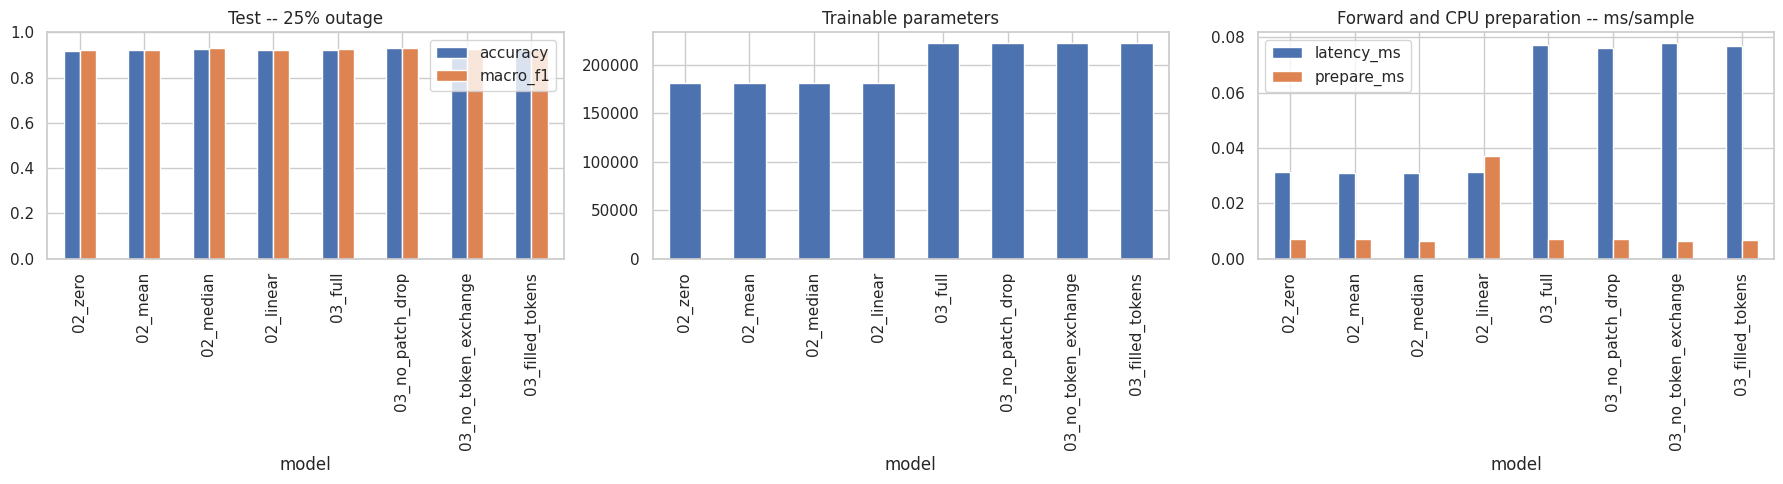

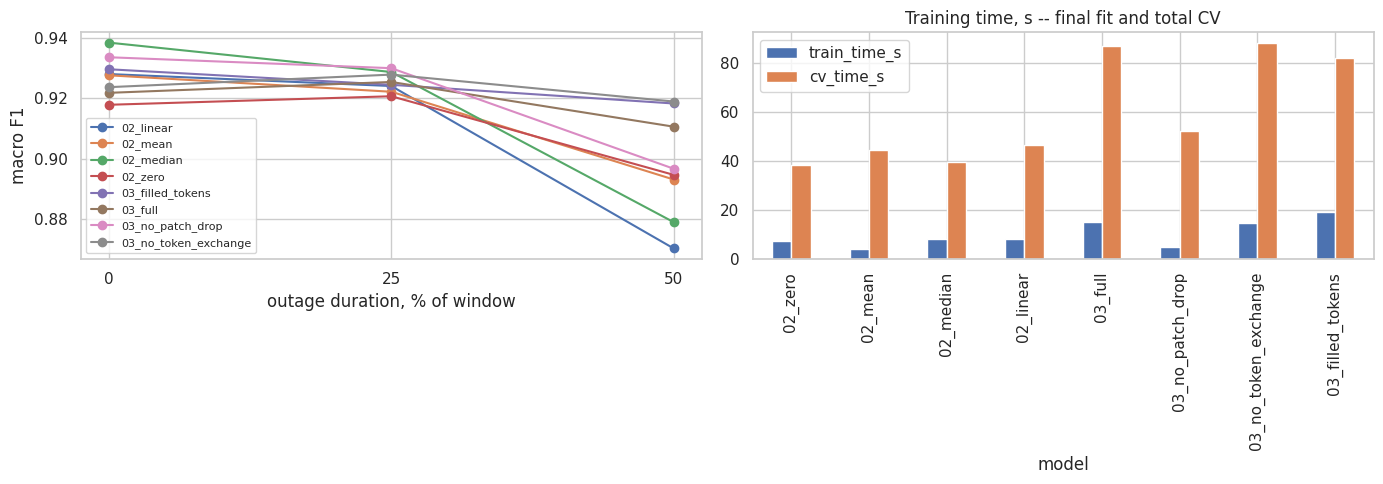

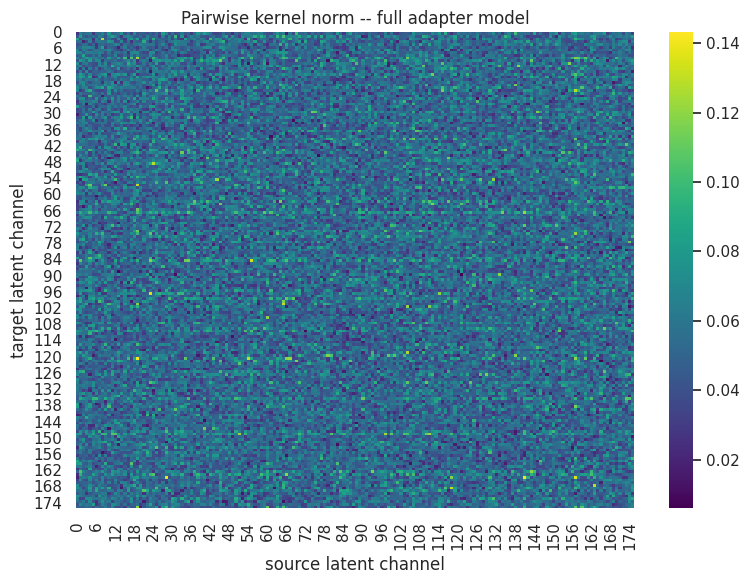

,full_minus_baseline,mask_minus_filled,patch_drop_effect,token_exchange_effect
gap_pct,,,,
0,-0.0167,0.0040,-0.0118,-0.0019
25,-0.0033,0.0055,-0.0046,-0.0024
50,0.0318,-0.0217,0.0140,-0.0084


По CV среди четырех способов заполнения выбран `02_median`: CV macro F1 = 0.9366.

При 0% отказа все каналы уже имеют разные частоты, но дополнительных блочных пропусков нет: выбранный baseline дает 0.9386, full CTF-inspired -- 0.9219. Поэтому на этом корпусе отдельного выигрыша от CTF-обработки только из-за несовпадающих частот не видно.

На основном test с отказом 25% выбранный baseline дает macro F1 = 0.9288, full CTF-inspired -- 0.9255, а вариант без patch dropout -- 0.9301. При умеренной missingness простая импутация остается конкурентоспособной; сравнение абляций на test использую только для интерпретации заранее заданных вариантов, а не для нового выбора модели.

При длинном отказе 50% full CTF-inspired выигрывает у CV-выбранного baseline: 0.9106 против 0.8788, delta = +0.0318. Patch dropout в этом режиме дает +0.0140 macro F1. Значит, специальная обработка пропусков становится полезнее, когда значительная часть временной структуры действительно потеряна.

Такой профиль результатов можно связать с природой UCI HAR: короткие инерциальные сигналы локально автокоррелированы, а несколько каналов дают частично избыточные признаки одного движения. Кроме того, задача -- классификация окна, а не точная реконструкция каждого скрытого отсчета. Поэтому при умеренных пропусках типичного значения канала часто достаточно, тогда как при 50% outage оставшейся временной информации уже заметно меньше. Это интерпретация данного корпуса, а не общий вывод о превосходстве медианной импутации.

Дополнительный обмен между channel tokens не улучшил aggregate macro F1 ни в одном из трех test-режимов: 0%: -0.0019, 25%: -0.0024, 50%: -0.0084. Это не означает, что межканальные связи бесполезны вообще: общий pairwise-backbone уже смешивает каналы, поэтому абляция измеряет только добавочный эффект token exchange поверх существующих связей.

Учет наблюдаемости внутри adapter относительно filled-tokens контроля дает +0.0055 macro F1 при 25% отказа, но -0.0217 при 50%. Поэтому отдельно маску нельзя назвать устойчиво полезной во всех режимах; наиболее ясный положительный эффект в full-конфигурации связан с train-time patch masking при тяжелых пропусках.

Цена full adapter -- 22.7% дополнительных параметров и примерно 2.48x forward latency относительно выбранного baseline на этом устройстве. Поэтому при умеренных пропусках усложнение здесь не окупается по качеству, а при тяжелых пропусках появляется измеримый запас устойчивости. Train time напрямую не сравниваю как стоимость архитектуры, потому что число финальных эпох выбирается отдельно по CV.

При 25% отказа token exchange дал положительную разницу у 4 из 9 test subjects. Это описательный результат одного полного запуска; малые различия не трактую как статистически доказанный эффект.

saved: REPORT.md


In [5]:
from IPython.display import Markdown, display

comparison = pd.concat([pd.read_csv(ROOT / "results/02_comparison.csv"),
                        pd.read_csv(ROOT / "results/03_comparison.csv")], ignore_index=True)
comparison.to_csv(ROOT / "results/comparison.csv", index=False)
main = comparison.query("gap_pct == 25").set_index("model")
columns = ["cv_f1_mean", "cv_f1_std", "accuracy", "balanced_accuracy", "macro_f1",
           "params", "final_epochs", "train_time_s", "cv_time_s", "latency_ms", "prepare_ms"]
display(main[columns].round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
main[["accuracy", "macro_f1"]].plot.bar(ax=axes[0], ylim=(0, 1))
main[["params"]].plot.bar(ax=axes[1], legend=False)
main[["latency_ms", "prepare_ms"]].plot.bar(ax=axes[2])
axes[0].set_title("Test -- 25% outage")
axes[1].set_title("Trainable parameters")
axes[2].set_title("Forward and CPU preparation -- ms/sample")
plt.tight_layout()
plt.savefig(ROOT / "figures/03_comparison.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, group in comparison.groupby("model"):
    axes[0].plot(group.gap_pct, group.macro_f1, marker="o", label=name)
axes[0].set(xlabel="outage duration, % of window", ylabel="macro F1", xticks=[0, 25, 50])
axes[0].legend(fontsize=8)
main[["train_time_s", "cv_time_s"]].plot.bar(ax=axes[1])
axes[1].set_title("Training time, s -- final fit and total CV")
plt.tight_layout()
plt.savefig(ROOT / "figures/03_robustness.png", dpi=150)
plt.show()

# Веса связей -- latent channels, не названия физических датчиков.
model = ChannelTokenPairwise()
model.load_state_dict(torch.load(ROOT / "results/03_full.pt", map_location="cpu", weights_only=True))
strength = model.backbone.imp1.mix.weight.detach().norm(dim=-1).numpy()
plt.figure(figsize=(8, 6))
sns.heatmap(strength, cmap="viridis")
plt.xlabel("source latent channel"); plt.ylabel("target latent channel")
plt.title("Pairwise kernel norm -- full adapter model")
plt.tight_layout()
plt.savefig(ROOT / "figures/03_pairwise_strength.png", dpi=150)
plt.show()

# Сравнения фиксированы заранее -- baseline выбираю только по CV.
best_baseline = main.loc[["02_zero", "02_mean", "02_median", "02_linear"], "cv_f1_mean"].idxmax()
pivot = comparison.pivot(index="gap_pct", columns="model", values="macro_f1")
effects = pd.DataFrame({
    "full_minus_baseline": pivot["03_full"] - pivot[best_baseline],
    "mask_minus_filled": pivot["03_no_patch_drop"] - pivot["03_filled_tokens"],
    "patch_drop_effect": pivot["03_full"] - pivot["03_no_patch_drop"],
    "token_exchange_effect": pivot["03_full"] - pivot["03_no_token_exchange"],
})
effects.to_csv(ROOT / "results/03_effects.csv")
display(effects.round(4))

# Проверяю, одинаково ли направление эффекта для разных test subjects.
a = pd.read_csv(ROOT / "results/03_full_test_25_predictions.csv")
b = pd.read_csv(ROOT / "results/03_no_token_exchange_test_25_predictions.csv")
subject_rows = []
for subject in sorted(a.subject.unique()):
    idx = a.subject == subject
    f_full = f1_score(a.loc[idx, "true"], a.loc[idx, "pred"], labels=range(6), average="macro", zero_division=0)
    f_no = f1_score(b.loc[idx, "true"], b.loc[idx, "pred"], labels=range(6), average="macro", zero_division=0)
    subject_rows.append({"subject": subject, "full_f1": f_full, "no_exchange_f1": f_no, "delta": f_full - f_no})
subject_table = pd.DataFrame(subject_rows)
subject_table.to_csv(ROOT / "results/03_subject_effects.csv", index=False)


def markdown_table(frame):
    # Без отдельной зависимости tabulate.
    text = frame.copy()
    for column in text.select_dtypes(include="float").columns:
        text[column] = text[column].map(lambda x: f"{x:.4f}")
    lines = ["| " + " | ".join(map(str, text.columns)) + " |",
             "| " + " | ".join(["---"] * len(text.columns)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in text.itertuples(index=False, name=None)]
    return "\n".join(lines)


conclusions = [
    f"По CV среди четырех способов заполнения выбран `{best_baseline}`: "
    f"CV macro F1 = {main.loc[best_baseline, 'cv_f1_mean']:.4f}."
]

baseline_0 = pivot.loc[0, best_baseline]
full_0 = pivot.loc[0, "03_full"]
conclusions.append(
    f"При 0% отказа все каналы уже имеют разные частоты, но дополнительных блочных пропусков нет: "
    f"выбранный baseline дает {baseline_0:.4f}, full CTF-inspired -- {full_0:.4f}. "
    "Поэтому на этом корпусе преимущества CTF-обработки только из-за разных частот не видно."
)

baseline_25 = pivot.loc[25, best_baseline]
full_25 = pivot.loc[25, "03_full"]
no_drop_25 = pivot.loc[25, "03_no_patch_drop"]
conclusions.append(
    f"На основном test с отказом 25% выбранный baseline дает macro F1 = {baseline_25:.4f}, "
    f"full CTF-inspired -- {full_25:.4f}. Абляция без patch dropout дает {no_drop_25:.4f}; "
    "это описательное test-сравнение, а не дополнительный выбор модели по test."
)

baseline_50 = pivot.loc[50, best_baseline]
full_50 = pivot.loc[50, "03_full"]
conclusions.append(
    f"При длинном отказе 50% full CTF-inspired выигрывает у CV-выбранного baseline: "
    f"{full_50:.4f} против {baseline_50:.4f}, delta = {full_50 - baseline_50:+.4f}. "
    f"Patch dropout в этом режиме дает {effects.loc[50, 'patch_drop_effect']:+.4f} macro F1, "
    "то есть его польза проявляется именно при более тяжелой missingness."
)

exchange = effects["token_exchange_effect"]
if (exchange < 0).all():
    conclusions.append(
        "Дополнительный обмен между channel tokens не улучшил aggregate macro F1 ни в одном из трех test-режимов: "
        + ", ".join(f"{int(g)}%: {v:+.4f}" for g, v in exchange.items()) + ". "
        "Это не означает, что межканальные связи бесполезны вообще: общий pairwise-backbone уже смешивает каналы, "
        "поэтому абляция измеряет только добавочный эффект token exchange поверх существующих связей."
    )
else:
    conclusions.append(
        "Эффект дополнительного token exchange зависит от режима: "
        + ", ".join(f"{int(g)}%: {v:+.4f}" for g, v in exchange.items()) + ". "
        "Абляция измеряет только добавочный обмен в adapter, поскольку pairwise-backbone сам уже смешивает каналы."
    )

conclusions.append(
    f"Учет наблюдаемости внутри adapter относительно filled-tokens контроля дает "
    f"{effects.loc[25, 'mask_minus_filled']:+.4f} macro F1 при 25% отказа, но "
    f"{effects.loc[50, 'mask_minus_filled']:+.4f} при 50%. Поэтому отдельно маску нельзя назвать "
    "устойчиво полезной во всех режимах; наиболее ясный выигрыш дает комбинация CTF-обработки и train-time patch masking "
    "при тяжелых пропусках."
)

param_overhead = 100 * (main.loc["03_full", "params"] / main.loc[best_baseline, "params"] - 1)
latency_ratio = main.loc["03_full", "latency_ms"] / main.loc[best_baseline, "latency_ms"]
conclusions.append(
    f"Цена full adapter -- {param_overhead:.1f}% дополнительных параметров и примерно {latency_ratio:.2f}x forward latency "
    "относительно выбранного baseline на этом устройстве. Train time напрямую не сравниваю как стоимость архитектуры, "
    "потому что число финальных эпох выбирается отдельно по CV."
)

conclusions.append(
    f"При 25% отказа token exchange дал положительную разницу у {(subject_table.delta > 0).sum()} "
    f"из {len(subject_table)} test subjects. Это описательный результат одного полного запуска; "
    "малые различия не трактую как статистически доказанный эффект."
)

configurations = {name: json.loads((ROOT / f"results/{name}_config.json").read_text())["hardware"]
                  for name in main.index}
unique_hardware = {json.dumps(cfg, ensure_ascii=False, sort_keys=True) for cfg in configurations.values()}
if len(unique_hardware) == 1:
    hardware_block = next(iter(configurations.values()))
    block = ("### Вычислительная конфигурация\n\nВсе восемь запусков выполнены в одной конфигурации.\n\n"
             "```json\n" + json.dumps(hardware_block, ensure_ascii=False, indent=2) + "\n```\n\n")
else:
    block = "### Вычислительная конфигурация\n\n```json\n" + json.dumps(configurations, ensure_ascii=False, indent=2) + "\n```\n\n"
eda_stats = pd.read_csv(ROOT / "results/01_channel_stats.csv")
block += "### Наблюдаемые train-каналы\n\n" + markdown_table(
    eda_stats[["channel", "sampling_hz", "mean", "median", "std", "lost_scheduled_pct"]])
block += "\n\n### Основной test, 25% отказа\n\n" + markdown_table(main[columns].reset_index())
block += "\n\n### Устойчивость -- macro F1\n\n" + markdown_table(pivot.reset_index())
block += "\n\n### Абляции -- разность macro F1\n\n" + markdown_table(effects.reset_index())
block += "\n\n### Эффект обмена по людям, 25% отказа\n\n" + markdown_table(subject_table)
block += "\n\n### Выводы\n\n" + "\n\n".join(conclusions)
block += "\n\n### Графики\n\n"
for filename, title in [
    ("01_observations.png", "Частоты и непрерывные пропуски"),
    ("01_masks_rates.png", "Расписание измерений и отказы"),
    ("03_comparison.png", "Качество и стоимость"),
    ("03_robustness.png", "Устойчивость и время обучения"),
    ("03_pairwise_strength.png", "Обученные pairwise-связи"),
]:
    block += f"![{title}](figures/{filename})\n\n"
report_path = ROOT / "REPORT.md"
report = report_path.read_text()
prefix = report.split("<!-- RESULTS_START -->")[0]
suffix = report.split("<!-- RESULTS_END -->")[1]
report_path.write_text(prefix + "<!-- RESULTS_START -->\n" + block + "<!-- RESULTS_END -->" + suffix)
(ROOT / "results/03_conclusions.txt").write_text("\n\n".join(conclusions))
display(Markdown("\n\n".join(conclusions)))
print("saved: REPORT.md")


### Вывод по эксперименту

На этом корпусе **медианная импутация действительно является сильным практическим baseline**.
При разных частотах без дополнительного outage она лучше full CTF-inspired по macro F1
(0.9386 против 0.9219), а при основном 25% outage результаты остаются близкими
(0.9288 против 0.9255). Поэтому для UCI HAR и умеренной missingness усложнение обработки
пропусков не дает убедительного выигрыша относительно простой медианы.

При 50% непрерывного outage вывод меняется: full CTF-inspired дает 0.9106 против 0.8788 у
CV-выбранного median baseline. Эффект patch dropout становится положительным (+0.0140 macro F1).
То есть идея обучения модели работать с отсутствующими временными patches имеет смысл прежде
всего при тяжелой потере наблюдений, когда простая импутация уже не сохраняет достаточно структуры.

Такой результат можно связать с природой UCI HAR: это короткие окна физических инерциальных
сигналов с локальной временной зависимостью и частичной избыточностью каналов, а целевая задача --
классификация активности, не точное восстановление каждого отсчета. Поэтому типичного значения
канала может хватать для решения класса при умеренных пропусках. Это объяснение относится к
данному корпусу и протоколу и не переносится автоматически на другие временные ряды.

Дополнительный `channel-token exchange` поверх Pairwise EdgeMTSC устойчивого выигрыша не дал.
Это не проверка тезиса «межканальные связи не нужны»: backbone уже содержит межканальное смешивание,
поэтому абляция показывает только отсутствие добавочной пользы именно от второго механизма обмена.